In [1]:
filt_conds = dict(
    Ms_min = 2e10,          # M_sol
    Ms_max = 5e12,          # M_sol
    r_min = 500,            # kpc
    r_max = 1000,           # kpc
    vt_min = 0,             # km/s
    vt_max = 300,           # km/s
    vr_min= -400,           # km/s
    vr_max = 0,             # km/s
    third_massive_m = 1.0,  # factor
    intruder_r = 3000,      # kpc
    intruder_m = 0.5        # factor
)

filts = dict()

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il

from lg_analogues import (
    load_header_constants,
    select_central_plus_largest_satellite_by_stellar_mass,
    find_pairs_periodic,
    isolation_filter_no_third_factor_x_in_same_group,
    isolation_filter_no_massive_intruder_within_distance_x,
    calculate_force_ratio,
    compute_tidal_dominance
)

basePath = os.path.expanduser("~/dsp26/dsp-cosmology")
snap = 99

In [3]:
# Load header constants (h and box size)
const = load_header_constants(basePath, snap)
h = const["h"]
box = const["box_ckpch"]

print("h:", h)
print("BoxSize [ckpc/h]:", box)

h: 0.6774
BoxSize [ckpc/h]: 205000.0


In [4]:
# Load subhalo fields needed for selection and pair finding
subhalo_fields = [ 
    "SubhaloPos",       # Spatial position within the periodic box (of the particle with the minium gravitational potential energy). Comoving coordinate. Units: ckpc/h 
    "SubhaloVel",       # Peculiar velocity of the group, computed as the sum of the mass weighted velocities of all particles/cells in this group, of all types. No unit conversion is needed. Units: km/s
    "SubhaloMass",      # Total mass of all member particle/cells which are bound to this Subhalo, of all types. Particle/cells bound to subhaloes of this Subhalo are NOT accounted for. Units: 1e10 Msun/h
    "SubhaloMassType",  # Total mass of all member particle/cells which are bound to this Subhalo, separated by type. Particle/cells bound to subhaloes of this Subhalo are NOT accounted for. Units: 1e10 Msun/h
    "SubhaloSFRinRad",  # Sum of the individual star formation rates of all gas cells in this subhalo, but restricted to cells within the radius of 𝑉𝑚𝑎𝑥. Units Msun/yr
    "SubhaloFlag",      # Flag field indicating suitability of this subhalo for certain types of analysis. If zero, this subhalo should generally be excluded, and is not thought to be of cosmological origin.
    "SubhaloGrNr"       # Index into the Group table of the FOF host/parent of this Subhalo. 
]

sub = il.groupcat.loadSubhalos(basePath, snap, fields=subhalo_fields)
print("All subhalos:", sub["count"])

All subhalos: 14485709


In [5]:
# Selection: centrals with stellar mass in window, plus largest satellite in window (per FoF group)
sample = select_central_plus_largest_satellite_by_stellar_mass(
    sub=sub,
    basePath=basePath,
    snap=snap,
    h=h,
    mstar_min=filt_conds["Ms_min"],
    mstar_max=filt_conds["Ms_max"],
)

print("Sample size:", sample.pos.shape[0])
print(f"Stellar mass range : [{float(sample.mstar.min()):.3e}, {float(sample.mstar.max()):.3e}] M_sol")
print("Groups represented:", np.unique(sample.grnr).size)

Sample size: 46595
Stellar mass range : [2.000e+10, 4.828e+12] M_sol
Groups represented: 39381


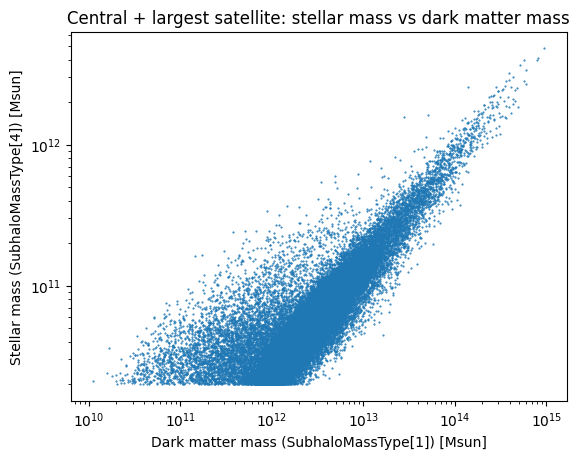

In [6]:
# SubhaloMassType units are 1e10 Msun/h
mstar = sample.mtype[:, 4].astype(np.float64) * 1e10 / h
mdm = sample.mtype[:, 1].astype(np.float64) * 1e10 / h

plt.figure()
plt.plot(mdm, mstar, ".", markersize=1.0)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Dark matter mass (SubhaloMassType[1]) [Msun]")
plt.ylabel("Stellar mass (SubhaloMassType[4]) [Msun]")
plt.title("Central + largest satellite: stellar mass vs dark matter mass")
plt.show()

In [7]:
# Pair finding (periodic), 500–1000 kpc
pairs = find_pairs_periodic(
    pos=sample.pos,
    vel=sample.vel,
    grnr=sample.grnr,
    h=h,
    box_ckpch=box,
    r_min_kpc=filt_conds["r_min"],
    r_max_kpc=filt_conds["r_max"],
)

print("Pairs:", pairs.i.size)
print("Same-host pairs:", int(pairs.same_host.sum()))
print("Different-host pairs:", int((~pairs.same_host).sum()))

Pairs: 2820
Same-host pairs: 2247
Different-host pairs: 573


In [8]:
# Isolation filter: no third subhalo in same FoF group(s) >= x 
# times more massive than the larger pair member

mask_group = isolation_filter_no_third_factor_x_in_same_group(
    sub=sub,
    pair_i=pairs.i,
    pair_j=pairs.j,
    sample_grnr=sample.grnr,
    sample_keep_idx_global=sample.keep_idx,
    h=h,
    x=filt_conds["third_massive_m"],
)

print("Pairs after group isolation:", int(mask_group.sum()))

Pairs after group isolation: 2737


In [9]:
# Isolation filter: No subhalos more massive than a `mass_factor`` times the combined
# mass of the pair within `r_iso_kpc` kpc from the center of mass of the pair.

mask_spatial = isolation_filter_no_massive_intruder_within_distance_x(
    sub=sub,
    pair_i=pairs.i,
    pair_j=pairs.j,
    sample_pos=sample.pos,
    sample_keep_idx_global=sample.keep_idx,
    h=h,
    box_ckpch=box,
    r_iso_kpc=filt_conds["intruder_r"],
    mass_factor=filt_conds["intruder_m"]
)

print("Pairs after spatial isolation:", int(mask_spatial.sum()))

Pairs after spatial isolation: 2817


In [10]:
keep_iso =  mask_spatial & mask_group
print(f"Pairs surviving isolation conditions: {np.sum(keep_iso)}")

Pairs surviving isolation conditions: 2734


In [11]:
keep_vel = (
    (pairs.v_t >= filt_conds["vt_min"])
    & (pairs.v_t <= filt_conds["vt_max"])
    & (pairs.v_r >= filt_conds["vr_min"])
    & (pairs.v_r <= filt_conds["vr_max"])
)
print(f"Isolated pairs surviving velocity conditions: {np.sum(keep_vel & keep_iso)}")

Isolated pairs surviving velocity conditions: 1779


In [12]:
f_ratios = calculate_force_ratio(sub, pairs, sample, h, box, search_radius_kpc=filt_conds["intruder_r"])
print(f"Range of force ratios: [{min(f_ratios):.3f}, {max(f_ratios):.3f}]")

internally_dom = f_ratios < 0.5
print(f"Internally dominated isolated pairs: {np.sum(keep_iso & internally_dom)}")

Range of force ratios: [0.036, 5197.234]
Internally dominated isolated pairs: 412


In [13]:
tidally_dom = compute_tidal_dominance(sub, pairs, sample, h, box, search_radius_kpc=filt_conds["intruder_r"])
print(f"Tidally dominant isolated pairs: {np.sum(keep_iso & tidally_dom)}")

Tidally dominant isolated pairs: 861


<>:60: SyntaxWarning: invalid escape sequence '\m'
<>:60: SyntaxWarning: invalid escape sequence '\m'
<>:63: SyntaxWarning: invalid escape sequence '\m'
<>:63: SyntaxWarning: invalid escape sequence '\g'
<>:60: SyntaxWarning: invalid escape sequence '\m'
<>:60: SyntaxWarning: invalid escape sequence '\m'
<>:63: SyntaxWarning: invalid escape sequence '\m'
<>:63: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_4567/3071247902.py:60: SyntaxWarning: invalid escape sequence '\m'
  linewidth=2, label=f'$\mathcal{{T}}_{{\mathrm{{sub}}}}$ (N={N_tidal_sub})', bw_adjust=bw)
/tmp/ipykernel_4567/3071247902.py:60: SyntaxWarning: invalid escape sequence '\m'
  linewidth=2, label=f'$\mathcal{{T}}_{{\mathrm{{sub}}}}$ (N={N_tidal_sub})', bw_adjust=bw)
/tmp/ipykernel_4567/3071247902.py:63: SyntaxWarning: invalid escape sequence '\m'
  linewidth=2, label=f'$\mathcal{{F}} \geq 0.5$ (N={N_ext_dom})', bw_adjust=bw)
/tmp/ipykernel_4567/3071247902.py:63: SyntaxWarning: invalid escape sequence '\g'


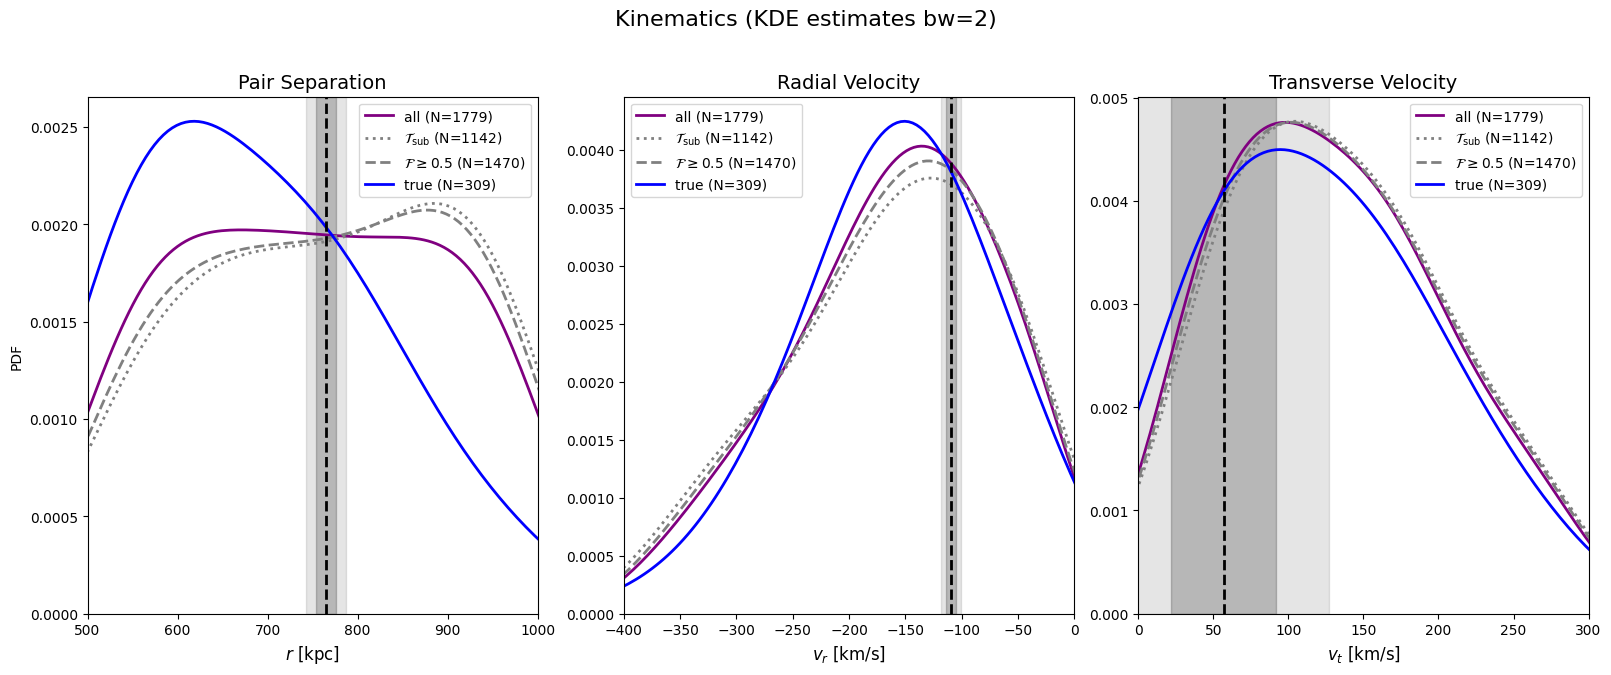

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


dist = pairs.dist_kpc[keep_vel & keep_iso]
vr = pairs.v_r[keep_vel & keep_iso]
vt = pairs.v_t[keep_vel & keep_iso]
bw = 2

# Observational constraints
obs_data = {
    'r':  {'val': 765, 'sigma': 11},
    'vr': {'val': -109.3, 'sigma': 4.4},
    'vt': {'val': 57, 'sigma': 35}
}

fig, axes = plt.subplots(1, 3, figsize=(16, 6), constrained_layout=True)

ranges = {
    'r':  [filt_conds["r_min"], filt_conds["r_max"]],
    'vr': [filt_conds["vr_min"], filt_conds["vr_max"]],
    'vt': [filt_conds["vt_min"], filt_conds["vt_max"]]
}

titles = ["Pair Separation", "Radial Velocity", "Transverse Velocity"]
x_labels = ["$r$ [kpc]", "$v_r$ [km/s]", "$v_t$ [km/s]"]
data_list = [dist, vr, vt]
obs_keys = ['r', 'vr', 'vt']

data_ext_dom = [
    pairs.dist_kpc[keep_vel & keep_iso & ~internally_dom],
    pairs.v_r[keep_vel & keep_iso & ~internally_dom],
    pairs.v_t[keep_vel & keep_iso & ~internally_dom]
]

data_tidal_sub = [
    pairs.dist_kpc[keep_vel & keep_iso & ~tidally_dom],
    pairs.v_r[keep_vel & keep_iso & ~tidally_dom],
    pairs.v_t[keep_vel & keep_iso & ~tidally_dom]
]

data_true = [
    pairs.dist_kpc[keep_vel & keep_iso & internally_dom & tidally_dom],
    pairs.v_r[keep_vel & keep_iso & internally_dom & tidally_dom],
    pairs.v_t[keep_vel & keep_iso & internally_dom & tidally_dom]
]

N_all = len(dist)
N_ext_dom = len(data_ext_dom[0])
N_tidal_sub = len(data_tidal_sub[0])
N_true = len(data_true[0])

for i, key in enumerate(obs_keys):
    # Plot Simulated Distribution with KDE
    sns.kdeplot(data_list[i], ax=axes[i], color="purple", linestyle='-', 
                linewidth=2, label=f'all (N={N_all})', bw_adjust=bw)
    
    sns.kdeplot(data_tidal_sub[i], ax=axes[i], color="gray", linestyle=':', 
                linewidth=2, label=f'$\mathcal{{T}}_{{\mathrm{{sub}}}}$ (N={N_tidal_sub})', bw_adjust=bw)
    
    sns.kdeplot(data_ext_dom[i], ax=axes[i], color="gray", linestyle='--', 
                linewidth=2, label=f'$\mathcal{{F}} \geq 0.5$ (N={N_ext_dom})', bw_adjust=bw)    
    
    sns.kdeplot(data_true[i], ax=axes[i], color="blue", linestyle='-', 
                linewidth=2, label=f'true (N={N_true})', bw_adjust=bw)
    
    # Set the specific Uchuu limits
    axes[i].set_xlim(ranges[key])
    
    # Observational uncertainty regions
    mu = obs_data[key]['val']
    std = obs_data[key]['sigma']
    
    # 2 Sigma Region - Darker (95% CI)
    axes[i].axvspan(mu - 2*std, mu + 2*std, color='black', alpha=0.1)
    # 1 Sigma Region - Lighter (68% CI)
    axes[i].axvspan(mu - std, mu + std, color='black', alpha=0.2)
    
    # Best-fit vertical line
    axes[i].axvline(mu, color='black', linestyle='--', linewidth=2)
    
    axes[i].set_title(titles[i], fontsize=14)
    axes[i].set_xlabel(x_labels[i], fontsize=12)
    axes[i].set_ylabel("")
    axes[i].legend()

axes[0].set_ylabel("PDF")
plt.suptitle(f"Kinematics (KDE estimates bw={bw})", fontsize=16, y=1.1)
plt.show()

<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\g'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\g'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_4567/3186100403.py:8: SyntaxWarning: invalid escape sequence '\m'
  f_legs = ["$\mathcal{{F}}< 0.5$", f"$\mathcal{{F}} \geq 0.5$"]
/tmp/ipykernel_4567/3186100403.py:8: SyntaxWarning: invalid escape sequence '\m'
  f_legs = ["$\mathcal{{F}}< 0.5$", f"$\mathcal{{F}} \geq 0.5$"]
/tmp/ipykernel_4567/3186100403.py:8: SyntaxWarning: invalid escape sequence '\g'
  f_legs = ["$\mathcal{{F}}< 0.5$", f"$\mathcal{{F}} \geq 0.5$"]
/tmp/ipykernel_4567/3186100403.py:11: SyntaxWarning: inval

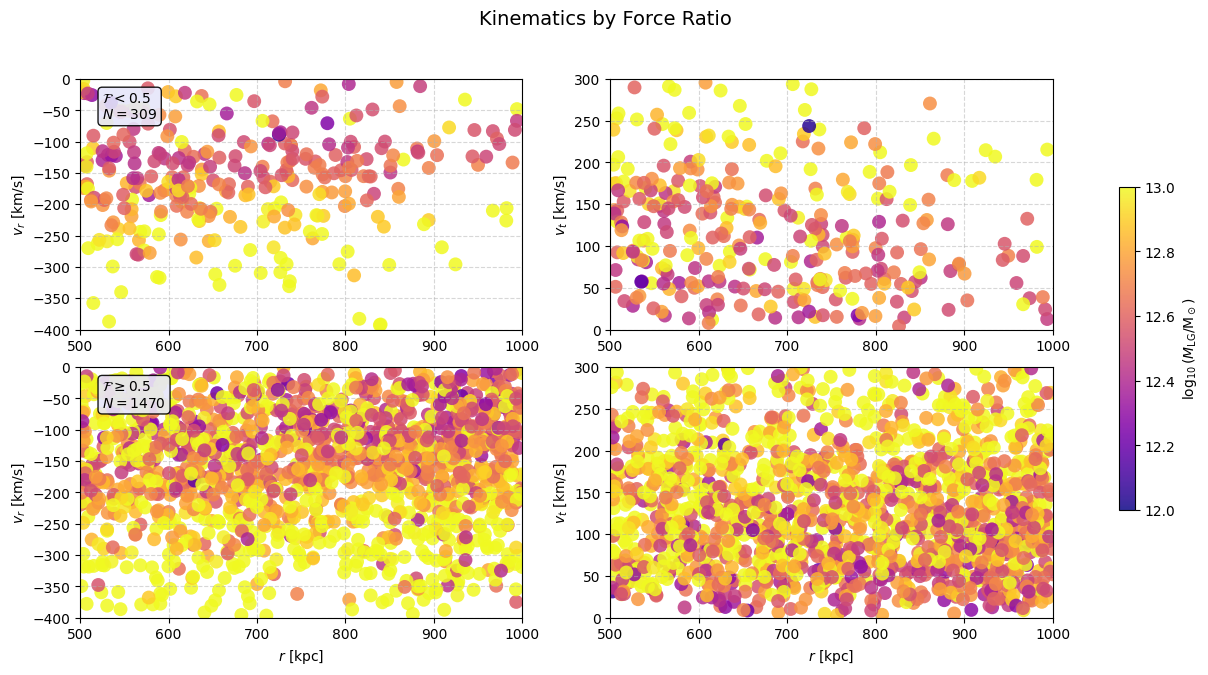

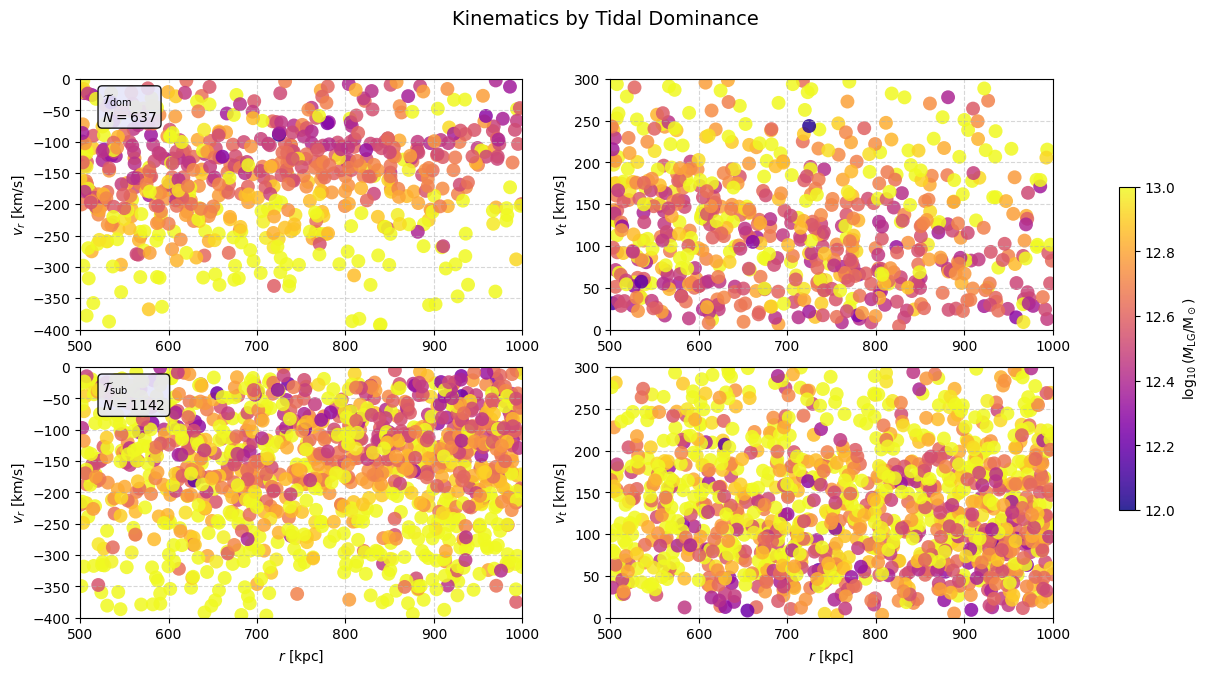

In [31]:
import matplotlib.pyplot as plt
import numpy as np

low_f_mask = (f_ratios < 0.5) & keep_iso & keep_vel
high_f_mask = (f_ratios >= 0.5) & keep_iso & keep_vel

f_masks = [low_f_mask, high_f_mask]
f_legs = ["$\mathcal{{F}}< 0.5$", f"$\mathcal{{F}} \geq 0.5$"]

tid_masks = [tidally_dom & keep_iso & keep_vel, ~tidally_dom & keep_iso & keep_vel]
tid_legs = ["$\mathcal{T}_{\mathrm{{dom}}}$", "$\mathcal{T}_{\mathrm{{sub}}}$"]


def build_kinematics_plots(masks, legs, title):
    fig, axes = plt.subplots(2, 2, figsize=(12, 6), constrained_layout=True)
    cmap = plt.get_cmap('plasma')

    for row, (mask, leg) in enumerate(zip(masks, legs)):
        # Data extraction logic from your function
        idx_i = pairs.i[mask]
        idx_j = pairs.j[mask]
        r = pairs.dist_kpc[mask]
        vr = pairs.v_r[mask]
        vt = pairs.v_t[mask]

        m_i = sub["SubhaloMass"][sample.keep_idx[idx_i]].astype(np.float64) * 1e10 / h
        m_j = sub["SubhaloMass"][sample.keep_idx[idx_j]].astype(np.float64) * 1e10 / h
        m_total_log = np.log10(m_i + m_j)

        # Column 0: Radial Velocity (vr)
        sc_vr = axes[row, 0].scatter(r, vr, c=m_total_log, s=100, alpha=0.85, cmap=cmap, edgecolors='none', vmin=12.0, vmax=13.0)
        axes[row, 0].set_ylabel(r'$v_r$ [km/s]')
        axes[row, 0].set_xlim(filt_conds["r_min"], filt_conds["r_max"])
        axes[row, 0].set_ylim(filt_conds["vr_min"], filt_conds["vr_max"])
        axes[row, 0].grid(True, linestyle='--', alpha=0.5)
        
        # Column 1: Transverse Velocity (vt)
        sc_vt = axes[row, 1].scatter(r, vt, c=m_total_log, s=100, alpha=0.85, cmap=cmap, edgecolors='none', vmin=12.0, vmax=13.0)
        axes[row, 1].set_ylabel(r'$v_t$ [km/s]')
        axes[row, 1].set_xlim(filt_conds["r_min"], filt_conds["r_max"])
        axes[row, 1].set_ylim(filt_conds["vt_min"], filt_conds["vt_max"])
        axes[row, 1].grid(True, linestyle='--', alpha=0.5)

        # Legend
        axes[row, 0].text(0.05, 0.95, f"{leg}\n$N = {len(r)}$", 
                        transform=axes[row, 0].transAxes, verticalalignment='top',
                        bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.9))

    for col in range(2):
        axes[1, col].set_xlabel(r'$r$ [kpc]')

    cb = fig.colorbar(sc_vt, ax=axes, location='right', label=r'$\log_{10}(M_{\mathrm{LG}} / \mathrm{M}_\odot)$', shrink=0.6)

    plt.suptitle(title, fontsize=14, y=1.1)
    plt.show()

build_kinematics_plots(f_masks, f_legs, "Kinematics by Force Ratio")
build_kinematics_plots(tid_masks, tid_legs, "Kinematics by Tidal Dominance")